<a href="https://colab.research.google.com/github/JenilGoti/Football-Player-Tracker./blob/main/Football_Player_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Football Player Tracker


dataset: https://app.roboflow.com/jenils-workspace-ykltq/football-player-detection-ryyjv-s97jf/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

In [2]:
!pip install ultralytics gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00


## Download Dataset from roboflow

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mKY55Q7h0JKyX3dAK5Uo")
project = rf.workspace("jenils-workspace-ykltq").project("football-player-detection-ryyjv-s97jf")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Football-Player-Detection-1 in yolov8:: 100%|██████████| 515/515 [00:00<00:00, 1988.32it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### What Gets Downloaded

In [5]:
import os
!cat {dataset.location}/data.yaml

names:
- ball
- goalkeeper
- player
- referee
nc: 4
roboflow:
  license: CC BY 4.0
  project: football-player-detection-ryyjv-s97jf
  url: https://universe.roboflow.com/jenils-workspace-ykltq/football-player-detection-ryyjv-s97jf/dataset/1
  version: 1
  workspace: jenils-workspace-ykltq
test: ../test/images
train: ../train/images
val: ../valid/images


## Download model

In [6]:
from ultralytics import YOLO
import torch

# This downloads YOLOv8 pretrained on COCO (80 classes)
model = YOLO("yolov8m.pt")

print(type(model.model))

<class 'ultralytics.nn.tasks.DetectionModel'>


## Model perameter freezing

In [7]:
# Freeze backbone
for name, param in model.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False   # Freeze pretrained layers
    else:
        param.requires_grad = True    # Train only detection head

# Count trainable params
trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Trainable parameters: 25,902,640


## Training the model

In [8]:
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    pretrained=True,
    optimizer="Adam",
    lr0=0.001,
    patience=10,
    name="football_project",
    plots=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Football-Player-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_project, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overla

## Evoluted the model

In [23]:
metrics = model.val()

print(f"mAP@50:     {metrics.box.map50:.3f}")
print(f"mAP@50-95:  {metrics.box.map:.3f}")
print(f"Precision:  {metrics.box.mp:.3f}")
print(f"Recall:     {metrics.box.mr:.3f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2887.1±960.9 MB/s, size: 234.2 KB)
val: Scanning /content/Football-Player-Detection-1/valid/labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 13.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2s/it 3.6s
                   all         38        905      0.946        0.8      0.837      0.553
                  ball         35         35       0.99      0.371      0.429      0.148
            goalkeeper         27         27      0.924      0.926      0.966      0.702
                player         38        754      0.958      0.976       0.99      0.763
               referee         38         89      0.911      0.925      0.963        0.6
Speed: 9.7ms preprocess, 35.2ms inference, 0.0ms loss, 7.5ms postprocess per image
Results saved to /content/runs

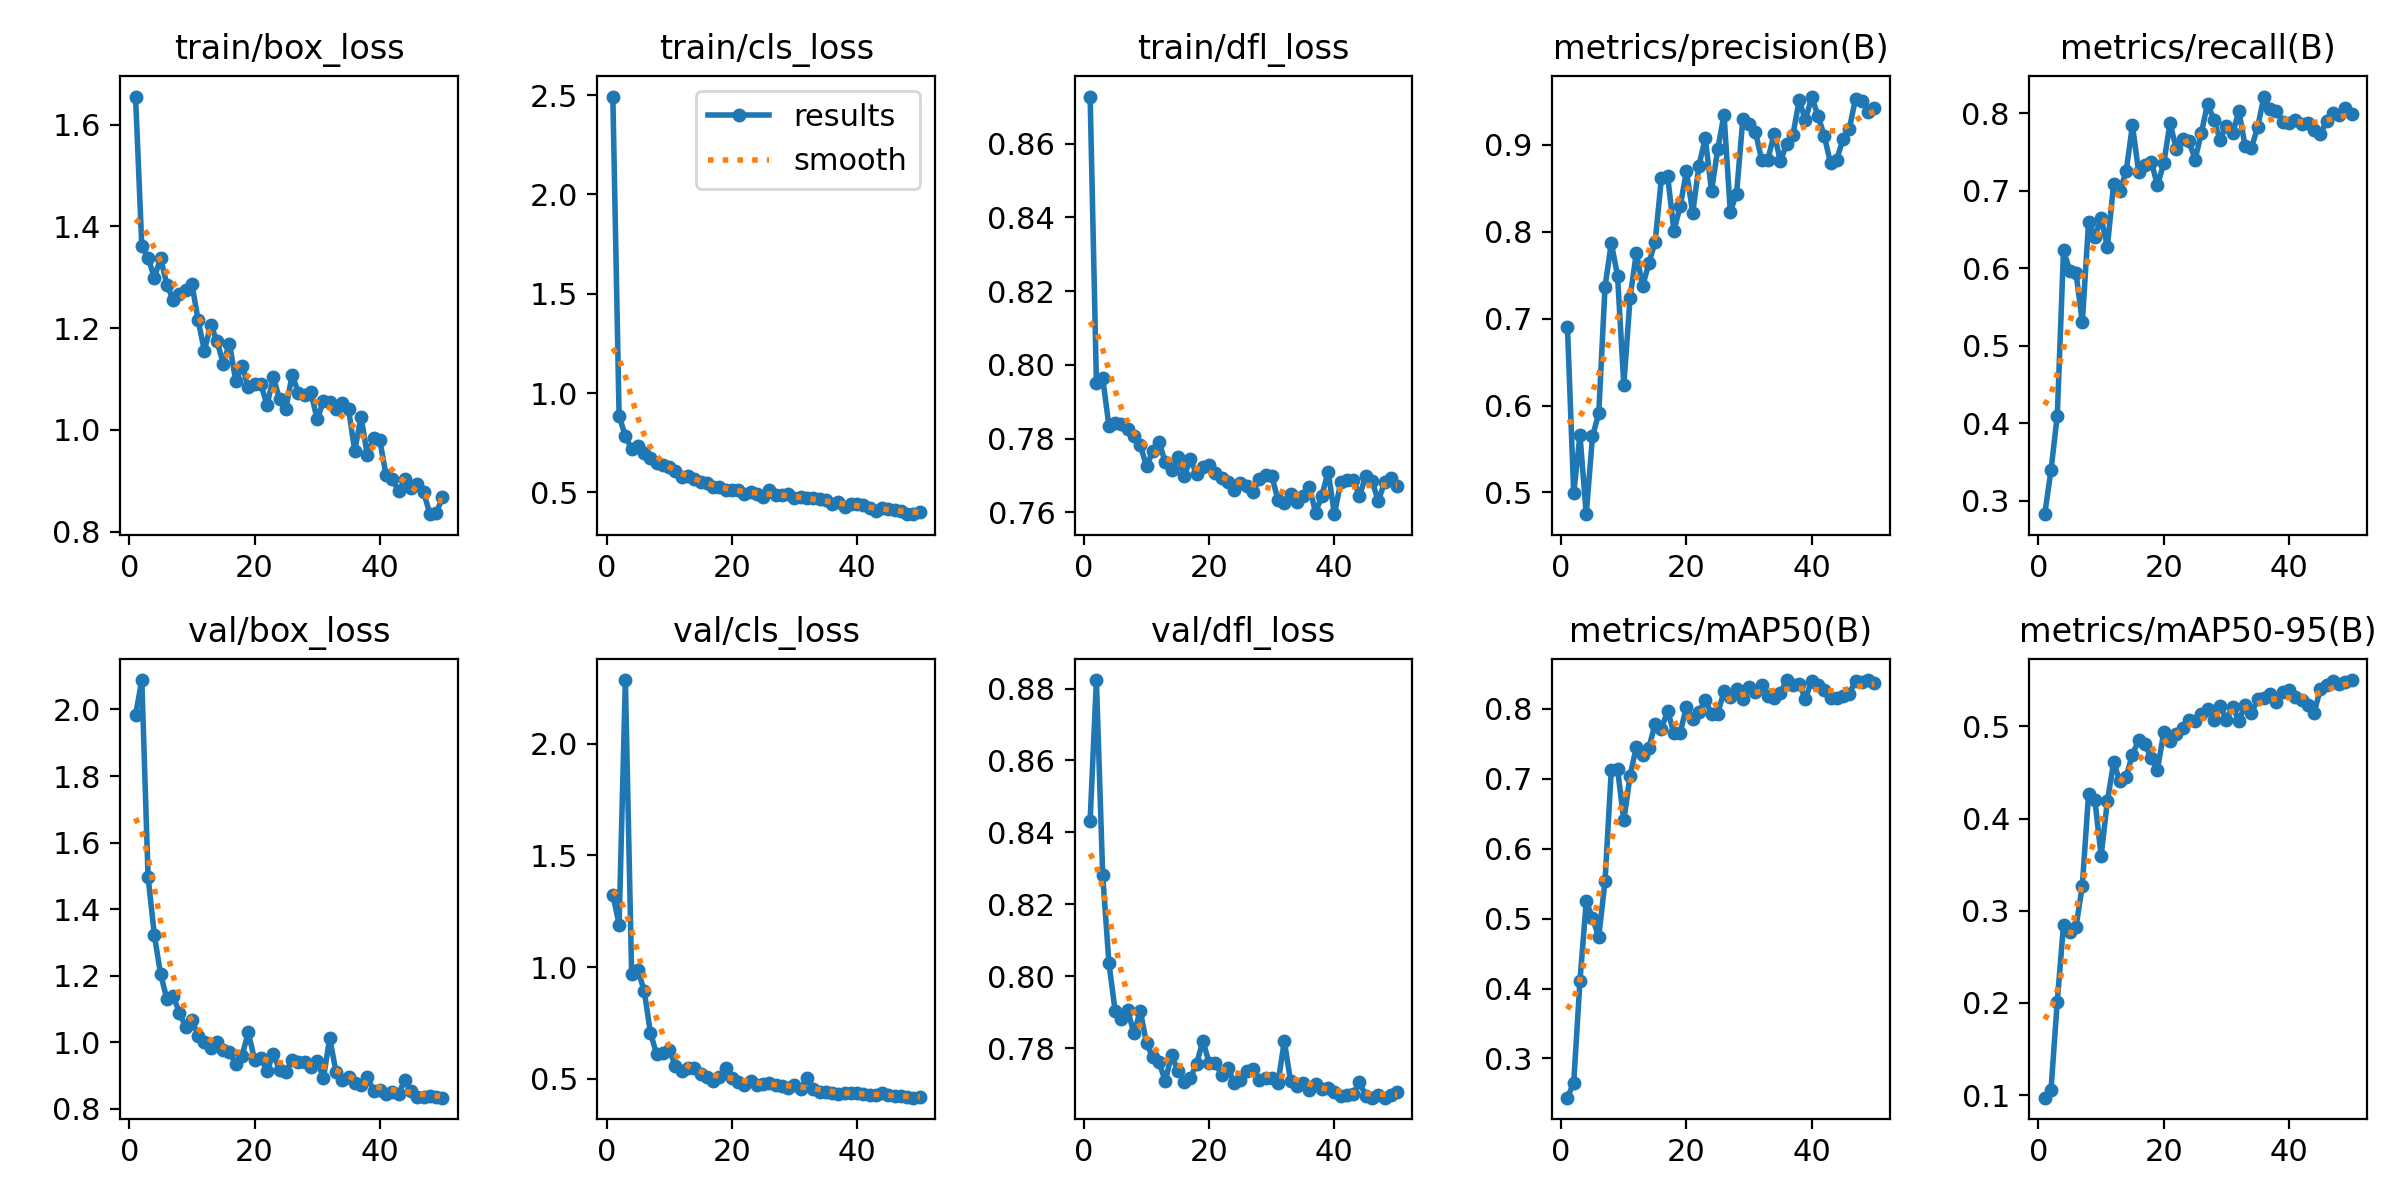

In [9]:
from IPython.display import Image
Image("runs/detect/football_project/results.png")

## Track Players in a Video

In [13]:

# Load trained model
model = YOLO("runs/detect/football_project/weights/best.pt")
video_path = "/content/Football-Player-Detection-1/testing.mp4"
# Run ByteTrack tracking
results = model.track(
    source=video_path,
    tracker="bytetrack.yaml",   # tracking algorithm
    save=True,                  # saves output video
    conf=0.4,                   # confidence threshold
    iou=0.5,                    # overlap threshold
    device=0,                   # GPU
    vid_stride=1,
    project="runs/track",
    name="output",
    exist_ok=True
)

print("Tracking done!")
print("Saved to: runs/track/")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/773) /content/Football-Player-Detection-1/testing.mp4: 352x640 14 players, 3 referees, 25.7ms
video 1/1 (frame 2/773) /content/Football-Player-Detection-1/testing.mp4: 352x640 14 players, 3 referees, 24.9ms
video 1/1 (frame 3/773) /content/Football-Player-Detection-1/testing.mp4: 352x640 15 players, 4 referees, 24.8ms
video 1/1 (frame 4/773) /content/Football-Player-Detection-1/testing.mp4: 352x640 15 players, 2 referees, 24.9ms
video 

## Gradio Demo App

In [21]:
import gradio as gr
from ultralytics import YOLO
import subprocess, os, tempfile, shutil

# Load your trained model
model = YOLO("runs/detect/football_project/weights/best.pt")

def track_football(video_path, confidence):
    """
    Takes uploaded video → runs tracking → returns tracked video
    """
    if video_path is None:
        return None, "Please upload a video!"

    # Output folder
    output_dir = tempfile.mkdtemp()

    # Run tracking
    model.track(
        source=video_path,
        tracker="bytetrack.yaml",
        save=True,
        conf=confidence,
        device=0,
        project=output_dir,
        name="result",
        exist_ok=True
    )

    # Find the saved AVI file
    avi_files = []
    for root, dirs, files in os.walk(output_dir):
        for f in files:
            if f.endswith(".avi"):
                avi_files.append(os.path.join(root, f))

    if not avi_files:
        return None, "Tracking failed — no output video found!"

    avi_path = avi_files[0]

    # Convert AVI → MP4 for browser playback
    mp4_path = os.path.join(output_dir, "tracked_output.mp4")
    subprocess.run([
        "ffmpeg", "-i", avi_path,
        "-vcodec", "libx264",
        "-crf", "23",
        mp4_path, "-y"
    ], capture_output=True)

    if not os.path.exists(mp4_path):
        return None, "Video conversion failed!"

    # Count detections
    total_detections = sum(
        len(r.boxes) for r in model.track(
            source=video_path,
            stream=True,
            conf=confidence
        )
    )

    stats = f"""
    Tracking Complete!
    ─────────────────────
    Video processed successfully
    Total detections : {total_detections}
    Confidence used  : {confidence}
    """

    return mp4_path, stats


# Build the Gradio UI
with gr.Blocks(theme=gr.themes.Soft(), title="⚽ Football Tracker") as app:

    gr.Markdown("""
    # ⚽ Football Player Tracker
    ### Powered by YOLOv8 + PyTorch + ByteTrack
    Upload a football match clip and the AI will detect and track every player!
    """)

    with gr.Row():
        # Left column — inputs
        with gr.Column():
            video_input = gr.Video(
                label="Upload Football Video",
            )
            confidence_slider = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.4,
                step=0.05,
                label="Detection Confidence"
            )
            track_btn = gr.Button(
                "Start Tracking!",
                variant="primary",
                size="lg"
            )

        # Right column — outputs
        with gr.Column():
            video_output = gr.Video(
                label="Tracked Output"
            )
            stats_output = gr.Textbox(
                label="Detection Stats",
                lines=7
            )

    # Examples section
    gr.Markdown("###Tips")
    gr.Markdown("""
    - Use videos **shorter than 30 seconds** for faster processing
    - **Lower confidence** = more detections (may include false positives)
    - **Higher confidence** = fewer but more accurate detections
    - Best results with **broadcast-angle** football footage
    """)

    # Connect button to function
    track_btn.click(
        fn=track_football,
        inputs=[video_input, confidence_slider],
        outputs=[video_output, stats_output]
    )

# ── Launch with public link ──────────────────────────
#app.launch(
 #   share=True,
  #  debug=True
#)

video 1/1 (frame 133/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 10 players, 6 referees, 584.7ms


The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.


## Deployed over Hugging_face

In [22]:
!pip install huggingface_hub -q

from huggingface_hub import notebook_login
notebook_login()

# Then push your app
app.launch(share=True)

video 1/1 (frame 136/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 10 players, 6 referees, 524.1ms
video 1/1 (frame 137/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 10 players, 5 referees, 842.3ms
video 1/1 (frame 138/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 10 players, 6 referees, 1534.2ms
video 1/1 (frame 139/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 11 players, 6 referees, 1363.0ms
video 1/1 (frame 140/403) /tmp/gradio/af2b481e5dc9bec76f2701316df47b6fbde8aadf0a7560d5739f8b040fa19ee2/Screen Recording 2026-04-22 at 09.47.20.mov: 352x640 11 players, 6 referees, 1491.2ms
video 1/1 (frame 141/403) /tmp/gradio/af2b481e5dc9bec76f2